<a href="https://colab.research.google.com/github/Uwais-ur-Rehman/ML-Project/blob/main/Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/Salary Data.csv')

In [ ]:
df1=pd.read_csv('/content/House Price Prediction Dataset.csv')

In [ ]:
df.sample(4)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
232,27.0,Female,Master's,Junior Research Scientist,1.5,50000.0
65,38.0,Female,Master's,Digital Marketing Manager,10.0,90000.0
196,41.0,Female,Bachelor's,Senior Marketing Coordinator,11.0,90000.0
345,33.0,Male,Bachelor's,Junior Business Analyst,4.0,60000.0


In [ ]:
df.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [ ]:
df1['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [ ]:
df1['Location'].value_counts()

,count
Location,
Downtown,558
Urban,485
Suburban,483
Rural,474


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


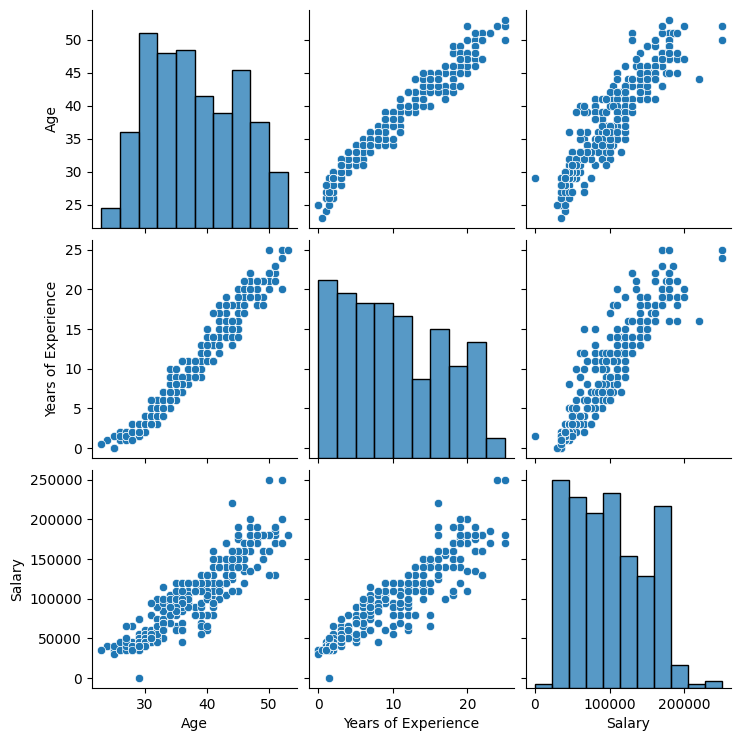

In [ ]:
sns.pairplot(df)
plt.show()

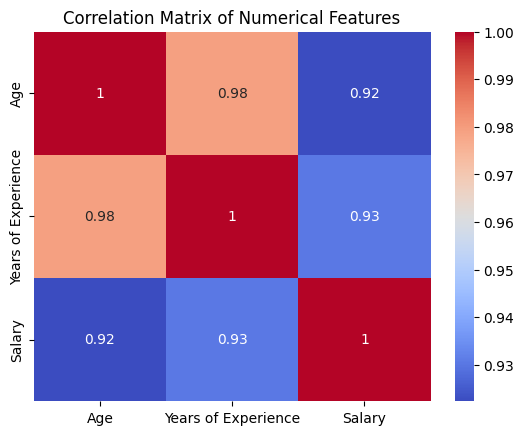

In [ ]:
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
df.sample(2)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
185,43.0,Male,Bachelor's,Senior IT Project Manager,14.0,130000.0
198,32.0,Female,Bachelor's,Junior Account Manager,5.0,55000.0


In [ ]:
df.isnull().sum()

,0
Age,2
Gender,2
Education Level,2
Job Title,2
Years of Experience,2
Salary,2


In [ ]:
print(df[df.isnull().any(axis=1)])

     Age Gender Education Level Job Title  Years of Experience  Salary
172  NaN    NaN             NaN       NaN                  NaN     NaN
260  NaN    NaN             NaN       NaN                  NaN     NaN


In [ ]:
print(df[df["Salary"].isnull()])

     Age Gender Education Level Job Title  Years of Experience  Salary
172  NaN    NaN             NaN       NaN                  NaN     NaN
260  NaN    NaN             NaN       NaN                  NaN     NaN


In [ ]:
df.dropna(subset=['Salary'],inplace=True)

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer

In [ ]:
x=df.drop(columns=['Salary','Job Title'])
y=df['Salary']

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
df.sample(2)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
311,35.0,Male,Bachelor's,Senior Financial Manager,9.0,100000.0
217,50.0,Female,PhD,Director of Operations,22.0,180000.0


In [ ]:
df['Education Level'].nunique()

3

In [ ]:
col_trans=ColumnTransformer(transformers=[
  ('scaler',MinMaxScaler(),['Age','Years of Experience']),
  ('ohe',OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore'),['Gender','Education Level'])
],remainder='drop')

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['Salary']),df['Salary'],test_size=0.2,random_state=42)

In [ ]:
x_train=col_trans.fit_transform(x_train)
x_test=col_trans.transform(x_test)

In [ ]:
x_train=pd.DataFrame(x_train,columns=col_trans.get_feature_names_out())
x_test=pd.DataFrame(x_test,columns=col_trans.get_feature_names_out())

In [ ]:
x_train.sample(3)

,scaler__Age,scaler__Years of Experience,ohe__Gender_Male,ohe__Education Level_Master's,ohe__Education Level_PhD
83,0.344828,0.32,1.0,1.0,0.0
241,0.241379,0.16,1.0,0.0,0.0
225,0.724138,0.60,0.0,0.0,1.0


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr=LinearRegression()
lr.fit(x_train,y_train)


LinearRegression()

In [ ]:
y_pred=lr.predict(x_test)

In [ ]:
y_pred_df = pd.DataFrame(y_pred, columns=["Predicted Salary"])
print(y_pred_df)

    Predicted Salary
0      174397.944851
1       92739.730470
2      129954.316276
3       87434.060663
4      155650.665069
..               ...
70      72886.551107
71     101926.663684
72      67281.151828
73     142633.359406
74      85732.717715

[75 rows x 1 columns]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R² Score:", r2)

MAE: 10599.921562305984
MSE: 231840874.0264617
R² Score: 0.903302221764233
